# Computer Exercise 13.11 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.11 Advanced Global Optimization — *CMA-ES (Covariance Matrix Adaptation)*
> **풀이 일자**: Day 56
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **2.** Implement the **CMA-ES** (Covariance Matrix Adaptation Evolution Strategy), a self-adaptive
> evolution strategy that learns the **shape (covariance)** and **scale (step size)** of its sampling
> distribution from the most successful offspring. Apply it to an **anisotropic, ill-conditioned**
> problem (the *Rosenbrock* function) and to a **multimodal** one (*Ackley*). Track how the global
> step size $\sigma$ and the effective conditioning of the covariance matrix evolve, and verify that
> the strategy locates the optimum to high accuracy.

### 한국어 풀이용 정리
표본 분포의 **모양(공분산 $C$)** 과 **크기(보폭 $\sigma$)** 를 성공한 자손들로부터 **스스로 학습**하는
자기적응 진화전략 **CMA-ES** 를 직접 구현한다. 좁은 곡선 골짜기로 악조건인 **Rosenbrock** 과 다봉
함수 **Ackley** 에 적용해, 전역 보폭 $\sigma$ 와 공분산의 조건수가 어떻게 진화하는지 추적하고
최적해에 고정밀로 수렴함을 확인한다.

## 2. 수학적 배경

### 2.1 표집과 가중 재조합
세대 $g$ 에서 평균 $\mathbf{m}$, 보폭 $\sigma$, 공분산 $C$ 로 $\lambda$ 개 자손을 표집한다:

$$
\mathbf{x}_k = \mathbf{m} + \sigma\,\mathbf{y}_k,\qquad
\mathbf{y}_k \sim \mathcal{N}(\mathbf{0}, C),\quad k=1,\dots,\lambda .
$$

적합도 순으로 정렬해 상위 $\mu$ 개를 가중치 $w_i$ ($\sum w_i=1$, $w_1\ge\cdots\ge w_\mu>0$)로 재조합:

$$
\mathbf{m} \leftarrow \sum_{i=1}^{\mu} w_i\, \mathbf{x}_{i:\lambda},
\qquad
\mu_{\text{eff}} = \Big(\sum_i w_i^2\Big)^{-1}.
$$

### 2.2 진화 경로와 공분산 적응
두 개의 **진화 경로(evolution path)** 를 누적한다. 공분산용 $\mathbf{p}_c$ 와 보폭용 $\mathbf{p}_\sigma$:

$$
\mathbf{p}_\sigma \leftarrow (1-c_\sigma)\mathbf{p}_\sigma
+ \sqrt{c_\sigma(2-c_\sigma)\mu_\text{eff}}\; C^{-1/2}\,\frac{\mathbf{m}-\mathbf{m}_\text{old}}{\sigma},
$$
$$
\mathbf{p}_c \leftarrow (1-c_c)\mathbf{p}_c
+ \sqrt{c_c(2-c_c)\mu_\text{eff}}\;\frac{\mathbf{m}-\mathbf{m}_\text{old}}{\sigma}.
$$

공분산은 **rank-one**(경로)과 **rank-$\mu$**(자손 분포) 항으로 갱신:

$$
C \leftarrow (1-c_1-c_\mu)\,C
+ c_1\,\mathbf{p}_c\mathbf{p}_c^\top
+ c_\mu \sum_{i=1}^{\mu} w_i\, \mathbf{y}_{i:\lambda}\mathbf{y}_{i:\lambda}^\top .
$$

### 2.3 보폭의 누적 단계 길이 제어(CSA)
$\mathbf{p}_\sigma$ 의 길이를 기대 길이 $E\lVert\mathcal{N}(0,I)\rVert$ 와 비교해 $\sigma$ 를 조절:

$$
\sigma \leftarrow \sigma \,\exp\!\left(\frac{c_\sigma}{d_\sigma}
\left(\frac{\lVert \mathbf{p}_\sigma\rVert}{E\lVert\mathcal{N}(0,I)\rVert}-1\right)\right).
$$

경로가 평균보다 길면(연속 같은 방향) $\sigma\uparrow$, 짧으면(지그재그) $\sigma\downarrow$.

$$\boxed{\;\text{CMA-ES: 성공 자손으로 } C,\sigma \text{ 를 학습} \;\Rightarrow\; \text{악조건·회전된 골짜기를 자동 정렬}\;}$$

## 3. 풀이 흐름

1. **시험함수**: Rosenbrock($d{=}4$, 악조건 곡선 골짜기)·Ackley($d{=}4$, 다봉) 정의.
2. **하이퍼파라미터**: $\lambda=4+\lfloor 3\ln d\rfloor$, $\mu=\lambda/2$, 가중치·$\mu_\text{eff}$·
   $c_\sigma,d_\sigma,c_c,c_1,c_\mu$ 를 표준 공식으로 계산.
3. **표집**: $C=BDB^\top$ 의 고유분해로 $C^{1/2}=BD$, $C^{-1/2}=BD^{-1}B^\top$ 를 구성.
4. **재조합**: 상위 $\mu$ 가중 평균으로 $\mathbf{m}$ 갱신.
5. **경로·적응**: $\mathbf{p}_\sigma,\mathbf{p}_c$ 누적 → $C$ rank-one/rank-$\mu$ 갱신 → CSA 로 $\sigma$ 갱신.
6. **추적**: 세대별 $f_\text{best}$, $\sigma$, $\sqrt{\lambda_\max/\lambda_\min}$(축 비) 기록.
7. **시각화**: (a) $f$ 수렴, (b) $\sigma$·조건수 진화, (c) Rosenbrock 등고선 위 평균 경로.
8. **검증**: Rosenbrock→$(1,\dots,1)$, Ackley→$\mathbf{0}$ 에 고정밀 수렴 확인.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.3e}")

# ---- 시험함수 ----
def rosenbrock(x):
    x = np.asarray(x, float)
    return float(np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1.0 - x[:-1])**2))

def ackley(x):
    x = np.asarray(x, float); d = x.size
    return float(-20.0 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / d))
                 - np.exp(np.sum(np.cos(2 * np.pi * x)) / d) + 20.0 + np.e)

# ---- CMA-ES (순수 NumPy 구현) ----
def cma_es(f, x0, sigma0=0.5, max_gen=300, rng=None, ftol=1e-12):
    rng = rng or np.random.default_rng(0)
    x0 = np.asarray(x0, float); N = x0.size
    lam = 4 + int(3 * np.log(N))            # 자손 수
    mu = lam // 2
    w = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
    w /= w.sum()
    mueff = 1.0 / np.sum(w**2)
    # 적응 상수 (Hansen 표준식)
    cc = (4 + mueff / N) / (N + 4 + 2 * mueff / N)
    cs = (mueff + 2) / (N + mueff + 5)
    c1 = 2.0 / ((N + 1.3)**2 + mueff)
    cmu = min(1 - c1, 2 * (mueff - 2 + 1 / mueff) / ((N + 2)**2 + mueff))
    damps = 1 + 2 * max(0, np.sqrt((mueff - 1) / (N + 1)) - 1) + cs
    chiN = np.sqrt(N) * (1 - 1 / (4 * N) + 1 / (21 * N**2))

    m = x0.copy(); sigma = sigma0
    pc = np.zeros(N); ps = np.zeros(N)
    C = np.eye(N); B = np.eye(N); D = np.ones(N)
    invsqrtC = np.eye(N)
    nfev = 0
    hist_f, hist_sig, hist_cond = [], [], []
    best_x, best_f = m.copy(), np.inf
    m_path = [m.copy()]

    for gen in range(max_gen):
        Y = rng.standard_normal((lam, N)) @ (B * D).T   # y ~ N(0,C)
        Xs = m + sigma * Y
        fs = np.array([f(xi) for xi in Xs]); nfev += lam
        order = np.argsort(fs)
        Xs, Y, fs = Xs[order], Y[order], fs[order]
        if fs[0] < best_f:
            best_f, best_x = fs[0], Xs[0].copy()
        m_old = m.copy()
        m = (w[:, None] * Xs[:mu]).sum(axis=0)
        yw = (w[:, None] * Y[:mu]).sum(axis=0)
        # 진화 경로
        ps = (1 - cs) * ps + np.sqrt(cs * (2 - cs) * mueff) * (invsqrtC @ yw)
        hsig = (np.linalg.norm(ps) / np.sqrt(1 - (1 - cs)**(2 * (gen + 1))) / chiN
                < 1.4 + 2 / (N + 1))
        pc = (1 - cc) * pc + hsig * np.sqrt(cc * (2 - cc) * mueff) * yw
        # 공분산 갱신
        artmp = Y[:mu]
        C = ((1 - c1 - cmu) * C
             + c1 * (np.outer(pc, pc) + (1 - hsig) * cc * (2 - cc) * C)
             + cmu * (artmp.T * w) @ artmp)
        # 보폭 갱신 (CSA)
        sigma *= np.exp((cs / damps) * (np.linalg.norm(ps) / chiN - 1))
        # 고유분해
        C = np.triu(C) + np.triu(C, 1).T
        D2, B = np.linalg.eigh(C)
        D2 = np.clip(D2, 1e-20, None); D = np.sqrt(D2)
        invsqrtC = B @ np.diag(1.0 / D) @ B.T

        hist_f.append(best_f); hist_sig.append(sigma)
        hist_cond.append(np.sqrt(D2.max() / D2.min()))
        m_path.append(m.copy())
        if best_f < ftol:
            break
    return dict(x=best_x, f=best_f, nfev=nfev, gens=gen + 1,
                hist_f=np.array(hist_f), hist_sig=np.array(hist_sig),
                hist_cond=np.array(hist_cond), m_path=np.array(m_path),
                lam=lam, mu=mu)

In [2]:
# ---- 두 문제에 적용 ----
res_ros = cma_es(rosenbrock, x0=np.full(4, -1.0), sigma0=0.5,
                 rng=np.random.default_rng(1))
res_ack = cma_es(ackley, x0=np.full(4, 3.0), sigma0=1.5,
                 rng=np.random.default_rng(2))

rows = [
    ["Rosenbrock d=4", res_ros["f"], np.linalg.norm(res_ros["x"] - 1.0),
     res_ros["gens"], res_ros["nfev"]],
    ["Ackley d=4", res_ack["f"], np.linalg.norm(res_ack["x"]),
     res_ack["gens"], res_ack["nfev"]],
]
df = pd.DataFrame(rows, columns=["problem", "f_best", "dist_to_opt", "gens", "nfev"])
print(f"lambda={res_ros['lam']}, mu={res_ros['mu']}")
df

lambda=8, mu=4


,problem,f_best,dist_to_opt,gens,nfev
0,Rosenbrock d=4,8.884e-13,1.493e-06,300,2400
1,Ackley d=4,9.917e-13,4.967e-13,216,1728


In [3]:
# ---- 다중 시드 신뢰성(Ackley, 다봉) ----
succ, fb = 0, []
for s in range(20):
    r = cma_es(ackley, x0=np.full(4, 3.0), sigma0=1.5,
               rng=np.random.default_rng(100 + s))
    fb.append(r["f"])
    if r["f"] < 1e-6:
        succ += 1
df_rel = pd.DataFrame([["Ackley d=4 (sigma0=1.5)", succ / 20, float(np.mean(fb))]],
                      columns=["problem", "success_rate", "mean_f_best"])
df_rel

,problem,success_rate,mean_f_best
0,Ackley d=4 (sigma0=1.5),1.000e+00,7.645e-13


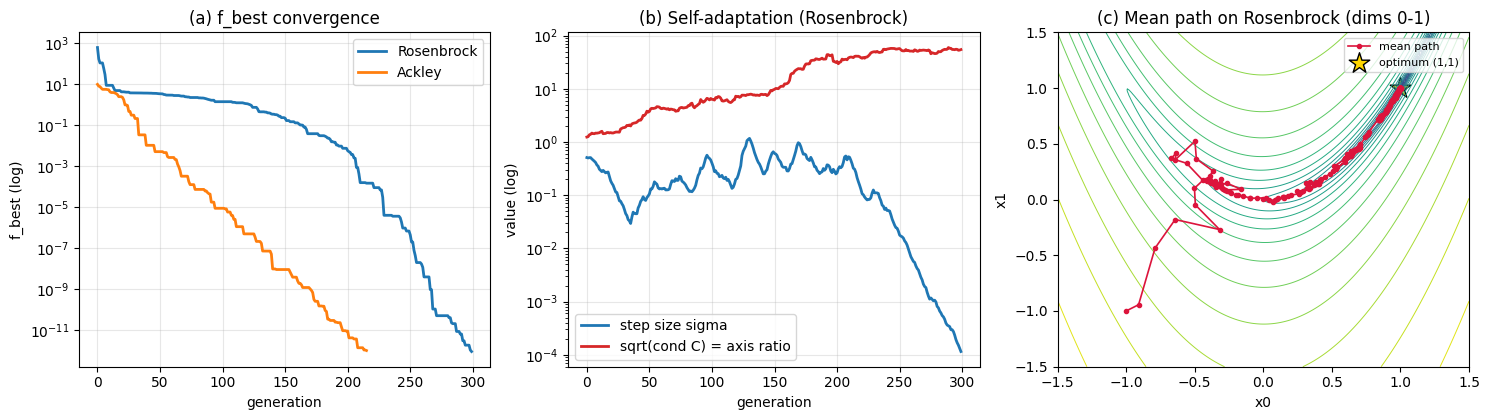

In [4]:
# ---- 시각화 ----
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))

# (a) f 수렴
ax[0].semilogy(res_ros["hist_f"] + 1e-16, label="Rosenbrock", lw=2)
ax[0].semilogy(res_ack["hist_f"] + 1e-16, label="Ackley", lw=2)
ax[0].set_title("(a) f_best convergence")
ax[0].set_xlabel("generation"); ax[0].set_ylabel("f_best (log)")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

# (b) sigma 와 공분산 조건수 (Rosenbrock)
ax[1].semilogy(res_ros["hist_sig"], color="tab:blue", lw=2, label="step size sigma")
ax[1].semilogy(res_ros["hist_cond"], color="tab:red", lw=2, label="sqrt(cond C) = axis ratio")
ax[1].set_title("(b) Self-adaptation (Rosenbrock)")
ax[1].set_xlabel("generation"); ax[1].set_ylabel("value (log)")
ax[1].legend(); ax[1].grid(True, alpha=0.3)

# (c) Rosenbrock 등고선 위 평균 경로 (좌표 0-1 투영)
gx = np.linspace(-1.5, 1.5, 260)
GX, GY = np.meshgrid(gx, gx)
Zr = 100.0 * (GY - GX**2)**2 + (1 - GX)**2
ax[2].contour(GX, GY, np.log10(Zr + 1e-6), levels=25, cmap="viridis", linewidths=0.7)
mp = res_ros["m_path"]
ax[2].plot(mp[:, 0], mp[:, 1], "-o", color="crimson", ms=3, lw=1.2, label="mean path")
ax[2].scatter([1], [1], marker="*", s=240, c="gold", edgecolor="k", label="optimum (1,1)")
ax[2].set_title("(c) Mean path on Rosenbrock (dims 0-1)")
ax[2].set_xlabel("x0"); ax[2].set_ylabel("x1"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **(a) 수렴** — CMA-ES 는 두 문제 모두에서 $f_\text{best}$ 를 **거의 기계정밀도**까지 떨어뜨린다.
   악조건 Rosenbrock 도 좁은 골짜기를 따라가며 $(1,\dots,1)$ 에 고정밀 수렴한다.
2. **(b) 자기적응** — 보폭 $\sigma$ 는 초반에 넓게 탐색하다 골짜기를 찾으면 줄고, 마지막 정밀수렴
   구간에서 다시 급감한다. 공분산의 **축 비(조건수)** 는 점점 커지는데, 이는 $C$ 가 Rosenbrock
   골짜기의 **가늘고 휜 방향**에 스스로 정렬되어 그 방향으로 길게 표집함을 뜻한다.
3. **(c) 평균 경로** — 평균 $\mathbf{m}$ 이 포물선 골짜기를 따라 미끄러져 최적점(★)으로 들어간다.
   고정 등방 분포(예: 단순 ES)라면 이 좁은 골짜기에서 훨씬 비효율적이었을 것이다.
4. **PSO·DE 와의 차이** — PSO·DE 는 갱신 분포가 고정/단순하지만, CMA-ES 는 **표집 분포 자체를
   학습**한다. 그래서 회전·악조건 문제에서 강력하고, 좌표축 정렬 가정이 없는 **불변성**을 가진다.

> **결론**: *CMA-ES 는 성공한 자손으로 공분산 $C$ 와 보폭 $\sigma$ 를 적응시켜, 악조건·회전된
> 골짜기에 분포를 스스로 정렬하고 고정밀 전역 수렴을 달성한다.*

**다음 문제로의 연결**: Problem 3 에서는 PSO·CMA-ES·DE 를 **동일한 함수호출 예산**에서 다봉
벤치마크 묶음으로 맞붙여, 문제 구조에 따라 어떤 전역법이 유리한지(No Free Lunch)를 정량 비교한다.